In [2]:
import os
import os
import sys
from datetime import datetime
from pathlib import Path
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)

notebook_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in [notebook_dir, *notebook_dir.parents] if (path / "utils").is_dir()),
    notebook_dir,
)    
import plotting
import pinns_infinite
import infinite
reload(plotting)
reload(infinite)
reload(pinns_infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns_infinite import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the tuned PIKAN hyperparameters

Reuse the best KAN configuration found during hyperparameter tuning (architecture,
learning rate, sampling settings, PDE parameters). We will keep everything fixed
and only vary `n_obs_k` below.

In [3]:
import pandas as pd

optimization_dir = repo_root / "main" / "02_hyperparameter_tunning" / "results_kan_infinite_optuna_2026-09-20_01-43-35"
summary = pd.read_csv(optimization_dir / "summary_metrics.csv")
best_trial = summary.loc[summary["mean_global_error"].idxmin()]

base_config = {
    "hidden_layers": int(best_trial["hidden_layers"]),
    "hidden_units": int(best_trial["hidden_units"]),
    "grid_size": int(best_trial["grid_size"]),
    "spline_order": int(best_trial["spline_order"]),
    "adam_lr": float(best_trial["adam_lr"]),
    "sampling": str(best_trial["sampling"]),
    "sigma": float(best_trial["sigma"]),
    "exp_scale": float(best_trial["exp_scale"]),
    "n_pde": int(best_trial["n_pde"]),
    "seed": int(best_trial["seed"]),
    "pde_alpha": float(best_trial["pde_alpha"]),
    "pde_beta": float(best_trial["pde_beta"]),
    "epsilon": float(best_trial["epsilon"]),
}

print("Base configuration (from optimization):")
for name, value in base_config.items():
    print(f"  {name}: {value}")


Base configuration (from optimization):
  hidden_layers: 3
  hidden_units: 15
  grid_size: 5
  spline_order: 4
  adam_lr: 0.0001
  sampling: gaussian
  sigma: 5.5
  exp_scale: 1.0
  n_pde: 1000
  seed: 2
  pde_alpha: 0.5
  pde_beta: 5.0
  epsilon: 1.0


## Experiment: vary the number of k observations

Fix `n_obs_u = 100` and sweep `n_obs_k` from 100 down to 0 in steps of 10 to see
how well the model can still recover the `k` field with fewer (or zero) direct
observations of `k`. One model is trained and saved per `n_obs_k` value.

In [4]:
N_OBS_U = 100
N_OBS_K_VALUES = list(range(100, -1, -10))  # 100, 90, ..., 10, 0

ADAM_ITERS = 2000
LBFGS_ITERS = 2000

SWEEP_DIR = Path("results") / "coefficient_field_sweep"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)


print(f"n_obs_u = {N_OBS_U}")
print(f"n_obs_k values = {N_OBS_K_VALUES}")
print(f"Models will be saved under: {SWEEP_DIR}")

n_obs_u = 100
n_obs_k values = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]
Models will be saved under: results/coefficient_field_sweep


## Train and save one model per `n_obs_k` value

In [ ]:
sweep_results = {}

for n_obs_k in N_OBS_K_VALUES:
    print(f"\n{'=' * 60}\nTraining with n_obs_k = {n_obs_k}\n{'=' * 60}")

    set_seed(base_config["seed"])

    model_u, model_k = build_models_KAN(
        device=device,
        hidden_layers=base_config["hidden_layers"],
        hidden_units=base_config["hidden_units"],
        grid_size=base_config["grid_size"],
        spline_order=base_config["spline_order"],
    )

    history = train_dual_network(
        model_u=model_u,
        model_k=model_k,
        adam_lr=base_config["adam_lr"],
        adam_iters=ADAM_ITERS,
        lbfgs_iters=LBFGS_ITERS,
        verbose=False,
        print_every=200,
        sampling=base_config["sampling"],
        sigma=base_config["sigma"],
        exp_scale=base_config["exp_scale"],
        n_obs_u=N_OBS_U,
        n_obs_k=n_obs_k,
        n_pde=base_config["n_pde"],
        seed=base_config["seed"],
        save_results=False,
        analytical_solution_inf=analytical_solution_inf,
        coefficient_inf=coefficient_inf,
        pde_alpha=base_config["pde_alpha"],
        pde_beta=base_config["pde_beta"],
        epsilon=base_config["epsilon"],
        device=device,
    )

    model_u.eval()
    model_k.eval()

    run_dir = SWEEP_DIR / f"n_obs_k_{n_obs_k}"
    run_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model_u.state_dict(), run_dir / "model_u.pt")
    torch.save(model_k.state_dict(), run_dir / "model_k.pt")

    sweep_results[n_obs_k] = {
        "run_dir": str(run_dir),
        "training_time_sec": history["training_time_sec"],
        "error_u": history["error_u"][-1] if history["error_u"] else None,
        "error_k": history["error_k"][-1] if history["error_k"] else None,
    }

    print(
        f"n_obs_k={n_obs_k} | time={history['training_time_sec']:.2f}s | "
        f"err_u={sweep_results[n_obs_k]['error_u']} | err_k={sweep_results[n_obs_k]['error_k']}"
    )
    print(f"Saved models to: {run_dir}")

# Persist the sweep summary alongside the per-run checkpoints.
sweep_summary = pd.DataFrame.from_dict(sweep_results, orient="index").rename_axis("n_obs_k").reset_index()
sweep_summary.to_csv(SWEEP_DIR / "sweep_summary.csv", index=False)
print(f"\nSweep complete. Summary saved to: {SWEEP_DIR / 'sweep_summary.csv'}")
sweep_summary

## Correct evaluation: true spatial generalization errors per `n_obs_k`

The `err_k` printed above only measures the fit at the (few) `k` observation
points used for training, so it shrinks trivially as those points become easier
to memorize — it does not reflect how well the model recovers `k` over the whole
domain. Reload every saved checkpoint and evaluate it on the same held-out grid
used throughout this notebook to get the real `u`/`k` global generalization
errors.

In [6]:
sweep_eval_results = {}

for n_obs_k in N_OBS_K_VALUES:
    run_dir = SWEEP_DIR / f"n_obs_k_{n_obs_k}"

    model_u, model_k = build_models_KAN(
        device=device,
        hidden_layers=base_config["hidden_layers"],
        hidden_units=base_config["hidden_units"],
        grid_size=base_config["grid_size"],
        spline_order=base_config["spline_order"],
    )
    model_u.load_state_dict(torch.load(run_dir / "model_u.pt", map_location=device))
    model_k.load_state_dict(torch.load(run_dir / "model_k.pt", map_location=device))
    model_u.eval()
    model_k.eval()

    _, _, X_obs_k_case, *_ = generate_dataset_inf(
        alpha=base_config["pde_alpha"],
        beta=base_config["pde_beta"],
        epsilon=base_config["epsilon"],
        eval_domain=(-10.0, 10.0, -10.0, 10.0),
        sampling=base_config["sampling"],
        sigma=base_config["sigma"],
        exp_scale=base_config["exp_scale"],
        n_obs_u=N_OBS_U,
        n_obs_k=n_obs_k,
        n_pde=base_config["n_pde"],
        plot=False,
        device=device,
        seed=base_config["seed"],
    )

    eval_out = evaluate_model_inf(
        model_u=model_u,
        model_k=model_k,
        analytical_solution=analytical_solution_inf,
        coefficient=coefficient_inf,
        train_xmin=-5, train_xmax=5, train_ymin=-5, train_ymax=5,
        eval_xmin=-10, eval_xmax=10, eval_ymin=-10, eval_ymax=10,
        n_grid=400,
        alpha=base_config["pde_alpha"],
        beta=base_config["pde_beta"],
        epsilon=base_config["epsilon"],
        device=device,
        plot=False,
        verbose=False,
    )

    sweep_eval_results[n_obs_k] = {
        "X_obs_k": X_obs_k_case,
        "K_pred": eval_out["K_pred"],
        "error_k": eval_out["error_k"],
        "err_u_global": eval_out["err_u_global"],
        "err_k_global": eval_out["err_k_global"],
        "err_u_inside": eval_out["err_u_inside"],
        "err_k_inside": eval_out["err_k_inside"],
        "err_u_outside": eval_out["err_u_outside"],
        "err_k_outside": eval_out["err_k_outside"],
    }

    print(
        f"n_obs_k={n_obs_k:3d} | "
        f"err_u_global={eval_out['err_u_global']:.3e} | "
        f"err_k_global={eval_out['err_k_global']:.3e}"
    )

sweep_eval_summary = pd.DataFrame(
    [
        {"n_obs_k": n, **{k: v for k, v in r.items() if k not in ("X_obs_k", "K_pred", "error_k")}}
        for n, r in sweep_eval_results.items()
    ]
).sort_values("n_obs_k", ascending=False).reset_index(drop=True)
sweep_eval_summary.to_csv(SWEEP_DIR / "sweep_eval_summary.csv", index=False)
sweep_eval_summary

n_obs_k=100 | err_u_global=4.920e-03 | err_k_global=1.611e-03
n_obs_k= 90 | err_u_global=2.656e-03 | err_k_global=2.829e-03
n_obs_k= 80 | err_u_global=2.592e-03 | err_k_global=1.361e-03
n_obs_k= 70 | err_u_global=2.273e-03 | err_k_global=1.747e-03
n_obs_k= 60 | err_u_global=2.760e-03 | err_k_global=2.118e-03
n_obs_k= 50 | err_u_global=1.827e-03 | err_k_global=5.650e-03
n_obs_k= 40 | err_u_global=4.227e-03 | err_k_global=1.166e-02
n_obs_k= 30 | err_u_global=2.944e-03 | err_k_global=4.756e-02
n_obs_k= 20 | err_u_global=3.480e-03 | err_k_global=8.719e-02
n_obs_k= 10 | err_u_global=3.818e-03 | err_k_global=1.340e-01
n_obs_k=  0 | err_u_global=2.347e-02 | err_k_global=2.972e+00


,n_obs_k,err_u_global,err_k_global,err_u_inside,err_k_inside,err_u_outside,err_k_outside
0,100,0.004920,0.001611,0.007998,0.000776,0.003894,0.001890
1,90,0.002656,0.002829,0.003407,0.001224,0.002406,0.003364
2,80,0.002592,0.001361,0.003940,0.001194,0.002142,0.001417
3,70,0.002273,0.001747,0.002454,0.001826,0.002212,0.001721
4,60,0.002760,0.002118,0.004406,0.001363,0.002212,0.002370
5,50,0.001827,0.005650,0.002529,0.003580,0.001593,0.006339
6,40,0.004227,0.011658,0.003902,0.017892,0.004335,0.009580
7,30,0.002944,0.047565,0.004308,0.045204,0.002490,0.048352
8,20,0.003480,0.087189,0.005516,0.107858,0.002801,0.080300
9,10,0.003818,0.133992,0.006891,0.072548,0.002794,0.154473


## k recovery for 100 / 50 / 0 k-observations

Three rows show the predicted `k` field and its absolute error for
`n_obs_k = 100, 50, 0`, sharing the same color scales for a direct comparison.
The bottom panel reports the global MAE (from the corrected evaluation above)
for every `n_obs_k` value in the sweep, from 0 to 100.

In [7]:
FIGURE_N_OBS_K = [100, 50, 10, 0]

# Inspect the |k_hat - k| distribution for each case to pick a shared vmax manually.
percentiles = [50, 90, 95, 99, 100]
for n_obs_k in FIGURE_N_OBS_K:
    err = sweep_eval_results[n_obs_k]["error_k"]
    stats = np.percentile(err, percentiles)
    stats_str = " | ".join(f"p{p}={s:.4f}" for p, s in zip(percentiles, stats))
    print(f"n_obs_k={n_obs_k:3d} | min={err.min():.4f} | mean={err.mean():.4f} | {stats_str}")

n_obs_k=100 | min=0.0000 | mean=0.0016 | p50=0.0007 | p90=0.0041 | p95=0.0061 | p99=0.0149 | p100=0.0319
n_obs_k= 50 | min=0.0000 | mean=0.0056 | p50=0.0029 | p90=0.0138 | p95=0.0201 | p99=0.0443 | p100=0.0834
n_obs_k= 10 | min=0.0000 | mean=0.1340 | p50=0.0997 | p90=0.3115 | p95=0.3635 | p99=0.4547 | p100=0.5768
n_obs_k=  0 | min=0.0000 | mean=2.9722 | p50=2.9029 | p90=5.5006 | p95=5.8635 | p99=7.6436 | p100=9.0953


Figure saved to: figures/coefficient_field_sampling_number_variation.png


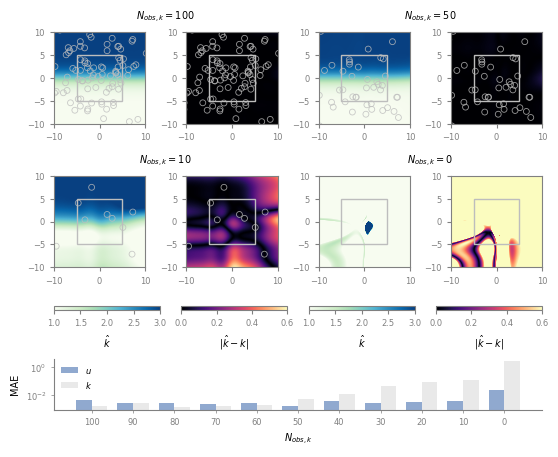

In [18]:
extent = [-10, 10, -10, 10]
K_VMIN, K_VMAX = 1.0, 3.0

# Fix these manually based on the percentiles printed above (shared across all cases).
ERR_K_VMIN, ERR_K_VMAX = 0.0, 0.6

GRAY = "gray"

CASES_PER_ROW = 2  # two (prediction, error) pairs side by side per row
n_cases = len(FIGURE_N_OBS_K)
n_case_rows = -(-n_cases // CASES_PER_ROW)  # ceil division

WIDTH_IN = 6.3  # width
scale = WIDTH_IN / (5.5 * CASES_PER_ROW)
fig = plt.figure(figsize=(WIDTH_IN, (3.0 * n_case_rows + 3.0) * scale))

# Nested gridspecs so the image rows can have generous spacing (avoiding
# label overlap) while the images stay close to their colorbars below.
outer_gs = fig.add_gridspec(2, 1, height_ratios=[n_case_rows, 0.06 + 0.7], hspace=0.10)
images_gs = outer_gs[0].subgridspec(n_case_rows, CASES_PER_ROW * 2, hspace=0.10, wspace=0.45)
bottom_gs = outer_gs[1].subgridspec(2, CASES_PER_ROW * 2, height_ratios=[0.06, 0.7], hspace=1.75)

col_images = {}

for i, n_obs_k in enumerate(FIGURE_N_OBS_K):
    case_row, col_pair = divmod(i, CASES_PER_ROW)
    case = sweep_eval_results[n_obs_k]
    X_obs_k_np = case["X_obs_k"].detach().cpu().numpy() if torch.is_tensor(case["X_obs_k"]) else np.asarray(case["X_obs_k"])

    ax_pred = fig.add_subplot(images_gs[case_row, col_pair * 2])
    ax_err = fig.add_subplot(images_gs[case_row, col_pair * 2 + 1])

    im_pred = ax_pred.imshow(case["K_pred"], extent=extent, origin="lower", cmap="GnBu", vmin=K_VMIN, vmax=K_VMAX, aspect="equal")
    im_err = ax_err.imshow(case["error_k"], extent=extent, origin="lower", cmap="magma", vmin=ERR_K_VMIN, vmax=ERR_K_VMAX, aspect="equal")
    col_images[col_pair * 2] = im_pred
    col_images[col_pair * 2 + 1] = im_err

    for ax in (ax_pred, ax_err):
        if X_obs_k_np.size:
            ax.scatter(X_obs_k_np[:, 0], X_obs_k_np[:, 1], facecolors="none", edgecolors="#BDBDBD", s=18, alpha=0.8, linewidths=0.6)
        rect = plt.Rectangle((-5, -5), 10, 10, fill=False, edgecolor="#BDBDBD", linewidth=1.0)
        ax.add_patch(rect)
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.tick_params(labelsize=6, colors=GRAY)
        for spine in ax.spines.values():
            spine.set_color(GRAY)

    # Single centered label above each (prediction, error) pair instead of per-subplot titles.
    x_center = (ax_pred.get_position().x0 + ax_err.get_position().x1) / 2
    y_top = ax_pred.get_position().y1
    fig.text(x_center, y_top + 0.015, f"$N_{{obs,k}}={n_obs_k}$", ha="center", va="bottom", fontsize=7)

# One narrow colorbar per column (4 total), with gray axis/ticks.
for col, im in sorted(col_images.items()):
    cax = fig.add_subplot(bottom_gs[0, col])
    label = r"$\hat{k}$" if col % 2 == 0 else r"$|\hat{k}-k|$"
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.set_label(label, fontsize=7, color="black")
    cbar.outline.set_edgecolor(GRAY)
    cax.tick_params(labelsize=6, colors=GRAY)

# Bottom panel: global MAE across the full sweep (0 to 100 k-observations)
ax_bar = fig.add_subplot(bottom_gs[1, :])
n_obs_k_all = sorted(sweep_eval_results.keys(), reverse=True)
err_u_all = [sweep_eval_results[n]["err_u_global"] for n in n_obs_k_all]
err_k_all = [sweep_eval_results[n]["err_k_global"] for n in n_obs_k_all]

x_pos = np.arange(len(n_obs_k_all))
width = 0.38

ax_bar.bar(x_pos - width / 2, err_u_all, width=width, color="#2255a080", label=r"$u$")
ax_bar.bar(x_pos + width / 2, err_k_all, width=width, color="#d6d6d683", label=r"$k$")

ax_bar.set_yscale("log")
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(n_obs_k_all, fontsize=6)
ax_bar.set_xlabel(r"$N_{obs,k}$", fontsize=7)
ax_bar.set_ylabel("MAE", fontsize=7)
ax_bar.tick_params(axis="both", labelsize=6, colors=GRAY, length=2, width=0.5)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.spines["bottom"].set_color(GRAY)
ax_bar.spines["left"].set_color(GRAY)
ax_bar.legend(fontsize=6, frameon=False)

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = figures_dir / "coefficient_field_sampling_number_variation.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
fig_path = figures_dir / "coefficient_field_sampling_number_variation.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()